[__<< Feature Engineering__](./04_Divvy_feature_engineering.ipynb) | [__XGBoost__](./05.1_Divvy_modeling_xgboost.ipynb) | [__RNN__](./05.2_Divvy_modeling_rnn.ipynb) | [__ARIMAX__](./05.3_Divvy_modeling_arimax.ipynb) | [__Ensemble__](./05.4_Divvy_modeling_ensemble.ipynb) | [__Home__](../README.md)

# Divvy: Bike Sharing Forecast
## Forecasting

__Dataset:__ [Divvy Data](https://divvybikes.com/system-data) \
__Author:__ [Dmitry Luchkin](https://www.linkedin.com/in/dmitry-luchkin/) \
__Date:__ May 2025

> **Attention**
>
> The data utilized in this project were sourced from the official public data provided by Divvy. All analysis, results, and insights presented in this notebook were conducted and formulated by Dmitry Luchkin. I declare that I am not affiliated with Divvy, Lyft, the City of Chicago, or any associated organizations. The views and interpretations expressed herein are solely my own and do not represent the positions or policies of these entities.

### Notebooks <a class="anchor" name='notebooks'></a>

+ [Initial Data Exploration](./01_Divvy_data_exploration.ipynb)
+ [Data Cleaning](./02_Divvy_data_cleaning.ipynb)
+ [Exploratory Data Analysis](./03_Divvy_exploratory_data_analysis.ipynb)
+ [Feature Engineering](./04_Divvy_feature_engineering.ipynb)
+ Modeling & Validation:
  - [XGBoost: Modeling & Validation](./05.1_Divvy_modeling_xgboost.ipynb)
  - [RNN: Modeling & Validation](./05.2_Divvy_modeling_rnn.ipynb)
  - [ARIMAX: Modeling & Validation](./05.3_Divvy_modeling_arimax.ipynb)
  - [Ensemble: Modeling & Validation](./05.4_Divvy_modeling_ensemble.ipynb)
+ __[Forecasting](./06_Divvy_forecasting.ipynb)__

### Import Libraries <a name='import-libraries'></a>

In [1]:
import os 
import sys
import pickle
import warnings

import pandas as pd
import numpy as np
import statsmodels as sm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sktime.split import temporal_train_test_split
from sktime.utils.plotting import plot_series

from pmdarima import auto_arima

warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
sys.path.append('../02_scripts/')

# import project code
from utils.plotting import notebook_setup
from utils.plotting.notebook_setup import TRAIN_COLOR, TEST_COLOR, FORECAST_COLOR
from utils.plotting.viz import plot_trips, distplot, check_residuals, plot_window_size
from utils.model.tools import load_dump

### Loading Data <a name='loading-data'></a>

In [3]:
train_filename = "../00_data/02_processed/divvy_train.pkl"
test_filename = "../00_data/02_processed/divvy_test.pkl"
train = None
test = None
# load training set
with open(train_filename, 'rb') as f:
        train = pickle.load(f)

# load test set
with open(test_filename, 'rb') as f:
        test = pickle.load(f)

In [862]:
# xgboost dump
xgboost_models_dump = load_dump("../03_models/01_xgboost/xgboost_models_dump.pkl")
# rnn dump
rnn_models_dump = load_dump("../03_models/02_rnn/rnn_models_dump.pkl")
# harimax dump
harimax_models_dump = load_dump("../03_models/03_arimax/arimax_models_dump.pkl")
# ensemble
ensemble_dump = load_dump("../03_models/04_ensemble/ensemble_models_dump.pkl")

### XGBoost: future

In [789]:
import os
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from utils.model.tools import add_lags
import xgboost as xgb
from xgboost import XGBRegressor
import holidays

def load(x):
    #print(f'{x} loading...')
    return pd.read_csv(x)
    
def load_weather_features():
    external_dir = "../00_data/03_external/weather/future/"
    files = [external_dir + file for file in os.listdir(external_dir) if file.endswith('.csv')]
    future_weather = pd.concat(map(load, files), ignore_index=True)
    future_weather['datetime'] = pd.to_datetime(future_weather['datetime'], format='mixed')
    future_weather.drop(columns=['name', 'tempmax', 'tempmin', 'feelslikemax',
                      'feelslikemin', 'dew', 'preciptype', 'solarradiation', 
                      'solarenergy', 'uvindex', 'severerisk', 'sunrise',
                      'sunset', 'moonphase', 'description', 'icon', 'stations'], inplace=True)
    df_split = future_weather["conditions"].str.get_dummies(sep=", ")
    future_weather = pd.concat([future_weather, df_split], axis=1)
    future_weather.drop(["conditions"], axis=1, inplace=True)
    future_weather.set_index("datetime", inplace=True)
    future_weather = future_weather.asfreq("D")

    return future_weather


def make_timestamp_features(start, end):
    data_range = pd.date_range(start=start, end=end, freq='D')
    df = pd.DataFrame(index=data_range)
    df['year'] = df.index.year
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['day'] = df.index.day
    df['season'] = df['month'] % 12 // 3 + 1 
    df['weekday'] = df.index.dayofweek
    
    return df

    
def make_holiday_feature(start, end):
    us_il_holidays = holidays.country_holidays('US', subdiv='IL')
    data_range = pd.date_range(start=start, end=end, freq='D')
    df = pd.DataFrame(index=data_range)
    df["is_holiday"] = df.index.map(lambda x: x in us_il_holidays)
    df["is_holiday"] = df["is_holiday"].astype(np.int32)
    
    return df


def make_time_index_feature(start, end):
    data_range = pd.date_range(start=start, end=end, freq='D')
    df = pd.DataFrame(index=data_range)
    df["time_index"] = np.arange(len(data_range))
    
    return df
    
    
def iterative_forecast_xgb(dump, historic_data, target_name, horizon):
    # get model details
    # list of group of predictors
    predictors = dump["xgboost"][target_name]["predictors"]
    # xgboost params were searched during the training
    xgb_params = dump["xgboost"][target_name]["model"]["params"]
    # transformation was appllied to the original series
    transformation = dump["xgboost"][target_name]["model"]["transformation"]
    bc_lambda = dump["xgboost"][target_name]["model"].get("lambda", None)
    # informative lags were added during the training
    informative_lags = dump["xgboost"][target_name]["model"]["lags"]

    print("*** Iterative Forecasting ***\n")
    print(f"Target Variable: {target_name}")
    print(f"Predictors: {predictors}")
    print(f"XGBoost Params: {xgb_params}")
    print(f"Transformation: {transformation} (lambda={bc_lambda})")
    print(f"Informative Lags: {informative_lags}")
    
    # prepare the data
    elements = {"time_index": {"features": ["time_index"], "add_lags": False}, 
                    "lags": {"features": [], "add_lags": True}, 
                    "timestamps": {"features": ["year", "quarter", "month", "day", "season", "weekday"], "add_lags": False}, 
                    "holidays": {"features": ["is_holiday"], "add_lags": False}, 
                    "weather": {"features": ["temp", "feelslike",
                                               "humidity", "precip", "precipprob", "precipcover", "snow", "snowdepth",
                                               "windgust", "windspeed", "winddir", "sealevelpressure", "cloudcover",
                                               "visibility", "Clear", "Freezing Drizzle/Freezing Rain", "Ice",
                                               "Overcast", "Partially cloudy", "Rain", "Snow"], "add_lags": False},
                   }
    
    features = []
    addlags = False
    for item in predictors:
        features.extend(elements[item]["features"])
        addlags |= elements[item]["add_lags"]

    train_xgb = pd.DataFrame(historic_data[target_name])

    # apply transformation if it is needed
    if transformation == "log":
        train_xgb[target_name] = np.log(train_xgb[target_name])
    elif transformation == "log1p":
        train_xgb[target_name] = np.log1p(train_xgb[target_name])
    elif transformation == "boxcox":
        train_xgb[target_name] = boxcox(train_xgb[target_name], lmbda=bc_lambda)

    # add time_index
    if "time_index" in predictors:
        time_index_df = make_time_index_feature(start=historic_data.index.min(),
                                            end=historic_data.index.max())
        train_xgb = pd.concat([train_xgb, time_index_df], axis=1)
        
    # add lags
    if addlags:
        train_xgb = add_lags(train_xgb, target_name, lags=informative_lags)

    # add timestamps
    if "timestamps" in predictors:
        timestamps_df = make_timestamp_features(start=historic_data.index.min(),
                                            end=historic_data.index.max())
        train_xgb = pd.concat([train_xgb, timestamps_df], axis=1)

    # add holidays
    if "holidays" in predictors:
        holidays_df = make_holiday_feature(start=historic_data.index.min(),
                                            end=historic_data.index.max())
        train_xgb = pd.concat([train_xgb, holidays_df], axis=1)

    # add weather
    if "weather" in predictors:
        weather_df = historic_data[elements["weather"]["features"]]
        train_xgb = pd.concat([train_xgb, weather_df], axis=1)

    X = train_xgb.drop(columns=[target_name])
    y = train_xgb[target_name]

    print("Retraining the model...")
    regressor = XGBRegressor(**xgb_params, objective='reg:squarederror', tree_method='hist')
    regressor.fit(X, y)

    print("Forecasting...")
    
    weather_features = load_weather_features()
    forecast_start = historic_data.index.max() + pd.Timedelta(days=1)
    forecast_end = historic_data.index.max() + pd.Timedelta(days=horizon)
    timestamps_features = make_timestamp_features(start=forecast_start, end=forecast_end)
    holidays_features = make_holiday_feature(start=forecast_start, end=forecast_end)
    historic_nrow = len(train_xgb)
    time_index_feature = pd.DataFrame({"time_index": np.arange(historic_nrow, historic_nrow+horizon)}, 
                                      index=pd.date_range(forecast_start, forecast_end, freq="D"))
    lags_forecast = pd.DataFrame(y)
    y_preds = [] # to keep predictions
    for h in np.arange(1, horizon + 1):
        time_index_forecast = time_index_feature.iloc[[h-1]] if "time_index" in predictors else None
        timestamps_forecast = timestamps_features.iloc[[h-1]] if "timestamps" in predictors else None
        holidays_forecast = holidays_features.iloc[[h-1]] if "holidays" in predictors else None
        weather_forecast = weather_features.iloc[[h-1]] if "weather" in predictors else None
        
        if addlags:
            next_index = lags_forecast.index.max() + pd.Timedelta(days=1)
            next_row = pd.DataFrame({target_name: [np.nan]}, index=[next_index])
            lags_forecast = pd.concat([lags_forecast, next_row], axis=0)
            lags_forecast = add_lags(lags_forecast, target_name, lags=informative_lags)
        else:
            lags_forecast = None
        
        test_xgb = pd.concat([time_index_forecast, 
                              lags_forecast.iloc[-1:, 1:],
                              timestamps_forecast, 
                              holidays_forecast, 
                              weather_forecast], axis=1, join='inner')
        
        y_pred = regressor.predict(test_xgb)[0]
        y_preds.append(y_pred)
        lags_forecast.iloc[-1, 0] = y_pred

    if transformation == "log":
        y_preds = np.exp(y_preds)
    elif transformation == "log1p":
        y_preds = np.expm1(y_preds)
    elif transformation == "boxcox":
        y_preds = inv_boxcox(y_preds, bc_lambda)

    print("Done!")
    
    return y_preds
    

In [790]:
h_data = pd.concat([train, test], axis=0)
horizon_forecast = 14

In [791]:
xgb_casual_regular_pred = iterative_forecast_xgb(xgboost_models_dump, h_data, "casual_regular_bike", horizon_forecast)

*** Iterative Forecasting ***

Target Variable: casual_regular_bike
Predictors: ('lags', 'timestamps', 'holidays', 'weather')
XGBoost Params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Transformation: boxcox (lambda=0.1829280195166226)
Informative Lags: [1, 3, 5, 6, 7, 13, 14]
Retraining the model...
Forecasting...
Done!


In [573]:
xgb_member_regular_pred = iterative_forecast_xgb(xgboost_models_dump, h_data, "member_regular_bike", horizon_forecast)

*** Iterative Forecasting ***

Target Variable: member_regular_bike
Predictors: ('time_index', 'lags', 'timestamps', 'holidays', 'weather')
XGBoost Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Transformation: None (lambda=None)
Informative Lags: [1, 2, 6]
Retraining the model...
Forecasting...
Done!


In [574]:
xgb_casual_electric_pred = iterative_forecast_xgb(xgboost_models_dump, h_data, "casual_electric_bike", horizon_forecast)

*** Iterative Forecasting ***

Target Variable: casual_electric_bike
Predictors: ('lags', 'timestamps', 'holidays', 'weather')
XGBoost Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Transformation: log1p (lambda=None)
Informative Lags: [1, 3, 5, 6, 7]
Retraining the model...
Forecasting...
Done!


In [575]:
xgb_member_electric_pred = iterative_forecast_xgb(xgboost_models_dump, h_data, "member_electric_bike", horizon_forecast)

*** Iterative Forecasting ***

Target Variable: member_electric_bike
Predictors: ('lags', 'timestamps', 'holidays', 'weather')
XGBoost Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Transformation: boxcox (lambda=0.705713587057188)
Informative Lags: [1, 5, 6]
Retraining the model...
Forecasting...
Done!


### RNN/LSTM: future

In [784]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

def make_rnn(window_size):
    # Define RNN model
    input_seq = Input(shape=(window_size, 1))         # time-dependent input (lags)
    input_static = Input(shape=(28,))                 # time-independent exogenous input

    x = LSTM(64, return_sequences=True)(input_seq)
    x = Dropout(0.15)(x)

    x = LSTM(256, return_sequences=False)(x)
    x = Dropout(0.25)(x)

    x = Concatenate()([x, input_static])    # merge sequence and static inputs
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)

    output = Dense(1, activation="softplus")(x)  # softplus ensures non-negative output

    model = Model(inputs=[input_seq, input_static], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
                  loss='mean_squared_error')

    return model
    

def iterative_forecast_rnn(dump, historic_data, target_name, horizon, verbose=1):
    # window size
    window_size = dump["rnn"][target_name]["window_size"] # timesteps

    print("*** Iterative Forecasting ***\n")
    print(f"Target Variable: {target_name}")
    print(f"Window Size: {window_size}")

    # Define the feature set: target + exogenous variables
    features = [target_name, 'is_holiday', 'year',
       'quarter', 'month', 'day', 'season', 'weekday', 'temp', 'feelslike',
       'humidity', 'precip', 'precipprob', 'precipcover', 'snow', 'snowdepth',
       'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover',
       'visibility', 'Clear', 'Freezing Drizzle/Freezing Rain', 'Ice',
       'Overcast', 'Partially cloudy', 'Rain', 'Snow']

    # Extract training data and scale to [0, 1]
    df_train = historic_data[features]
    
    y_scaler = MinMaxScaler(feature_range=(0, 1))
    X_scaler = MinMaxScaler(feature_range=(0, 1))

    y_scaled = y_scaler.fit_transform(df_train[[target_name]].values)
    X_scaled = X_scaler.fit_transform(df_train.drop(columns=[target_name]).values)
    
    df_train_scaled = np.hstack([y_scaled, X_scaled])
    
    # Create sequences of lagged target values for LSTM input
    X_train = []
    y_train = []
    for i in range(window_size, len(df_train)):
        X_train.append(y_scaled[i - window_size: i, 0])  # lagged y values
        y_train.append(y_scaled[i, 0])                   # next y value

    X_train, y_train = np.array(X_train), np.array(y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))  # shape: (samples, time steps, 1 feature)

    # Static features (exogenous variables) from the same period
    X_train_static = np.array(X_scaled[window_size:])

    model = make_rnn(window_size)

    # Learning rate scheduling and early stopping
    lr_scheduler = ReduceLROnPlateau(monitor="loss", factor=0.8, patience=15, min_lr=1e-6)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    print("Retraining...")
    
    # Train the model with 10% of the data used as validation set (last part of training set)
    history = model.fit([X_train, X_train_static], y_train,
                        epochs=100, batch_size=64,
                        verbose=verbose, callbacks=[early_stop, lr_scheduler])

    # -------- Prediction Phase -------- #

    print("Forecasting...")
    
    weather_features = load_weather_features()
    forecast_start = historic_data.index.max() + pd.Timedelta(days=1)
    forecast_end = historic_data.index.max() + pd.Timedelta(days=horizon)
    timestamps_features = make_timestamp_features(start=forecast_start, end=forecast_end)
    holidays_features = make_holiday_feature(start=forecast_start, end=forecast_end)

    X_static = pd.concat([holidays_features, 
                         timestamps_features, 
                         weather_features], axis=1, join="inner")[:horizon]

    X_static_scaled = X_scaler.transform(X_static.values)

    y_preds = [] # to keep predictions
    inputs = y_scaled[-window_size:, 0]
    for h in range(horizon):
        X_static_row = X_static_scaled[h].reshape(1, -1)
        X_test = np.reshape(inputs, (1, window_size, 1))
        
        pred_y = model.predict([X_test, X_static_row], verbose=verbose)
        inputs = np.append(inputs[1:], pred_y[0])
        y_preds.append(pred_y[0])
    
    y_preds = np.array(y_preds).reshape(-1, 1)
    y_pred_inv = y_scaler.inverse_transform(y_preds)

    print("Done!")
    
    return y_pred_inv.ravel()

In [793]:
rnn_casual_regular_pred = iterative_forecast_rnn(rnn_models_dump, h_data, "casual_regular_bike", horizon=horizon_forecast, verbose=0)

*** Iterative Forecasting ***

Target Variable: casual_regular_bike
Window Size: 90
Retraining...
Forecasting...
Done!


### ARIMAX: future

In [805]:
for key, item in harimax_models_dump["arimax"].items():
    if item["level"] == "bottom":
        print(f"{key}: {item['model']['forecast_type']}")

casual_regular_bike: iterative
casual_electric_bike: iterative
member_regular_bike: iterative
member_electric_bike: iterative


In [856]:
from utils.model.arimax import make_harmonic_features, safe_boxcox
from statsmodels.tsa.statespace.sarimax import SARIMAX

def iterative_forecast_harimax(dump, historic_data, target_name, horizon):
    order = dump["arimax"][target_name]["model"]["order"]
    d = dump["arimax"][target_name]["model"]["d"] # is not needed, it is in the order
    #forecast_type = dump["arimax"][target_name]["model"]["forecast_type"] # is not needed

    harmonic_periods=[7, 12, 30.44, 91.31, 182.62, 365.25]
    harmonics_per_periods=[3, 3, 3, 3, 3, 3]
    exog_features = ['is_holiday', 'year',
       'quarter', 'month', 'day', 'season', 'weekday', 'temp', 'feelslike',
       'humidity', 'precip', 'precipprob', 'precipcover', 'snow', 'snowdepth',
       'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover',
       'visibility', 'Clear', 'Freezing Drizzle/Freezing Rain', 'Ice',
       'Overcast', 'Partially cloudy', 'Rain', 'Snow']
    steps_ahead = 14

    print("*** Iterative Forecasting ***\n")
    print(f"Target Variable: {target_name}")
    print(f"ARIMA Model Order: {order}")
    print(f"Difference: {d}")

    # box-cox transformation
    train_transformed, train_lambda, shift = safe_boxcox(historic_data[target_name])
    # farmonic features
    t = np.arange(len(historic_data))
    train_harmonics = make_harmonic_features(t, 
                                             periods=harmonic_periods, 
                                             harmonics_per_periods=harmonics_per_periods)
    # searching the model
    print("Retraining...")
    train_data = train_transformed[:-steps_ahead]
    X = np.column_stack([train_harmonics[:-steps_ahead], historic_data.iloc[:-steps_ahead][exog_features].values])
            
    model = SARIMAX(train_data, 
                    exog=X, 
                    order=order)
    results = model.fit(maxiter=100, method='powell')
    
    sarima_test_preds = []

    bar_length = 50
    # warm up the model
    print("Warming up the model...")

    for i in range(len(train_transformed) - steps_ahead, len(train_transformed)):
        exog = np.hstack([train_harmonics[i], historic_data.iloc[i][exog_features].values]).reshape(1, -1)
        pred = results.forecast(steps=1, exog=exog)[0]
        results = results.append(train_transformed[[i]], exog=exog) # update the model

    # prediction
    print("Iterative Forecasting...")

    weather_features = load_weather_features()
    forecast_start = historic_data.index.max() + pd.Timedelta(days=1)
    forecast_end = historic_data.index.max() + pd.Timedelta(days=horizon)
    timestamps_features = make_timestamp_features(start=forecast_start, end=forecast_end)
    holidays_features = make_holiday_feature(start=forecast_start, end=forecast_end)

    X_static = pd.concat([holidays_features, 
                         timestamps_features, 
                         weather_features], axis=1, join="inner")[:horizon]
    
    for i in range(len(train_transformed), len(train_transformed) + horizon):
        test_harmonics = make_harmonic_features(np.arange(i, i + 1), 
                                                         periods=harmonic_periods, 
                                                         harmonics_per_periods=harmonics_per_periods)
        exog = np.hstack([test_harmonics, X_static.iloc[i-len(train_transformed)][exog_features].values.reshape(1, -1)])
        y_pred = results.forecast(steps=1, exog=exog)[0]
        sarima_test_preds.append(y_pred)
        results = results.append([y_pred], exog=exog)
            
    print("Boxcox Invertion...")
    harmonic_forecast = inv_boxcox(sarima_test_preds, train_lambda) - shift
    
    print("Done!")
    
    return harmonic_forecast

In [853]:
harimax_casual_regular_pred = iterative_forecast_harimax(harimax_models_dump, h_data, "casual_regular_bike", 
                                                         horizon=horizon_forecast)

*** Iterative Forecasting ***

Target Variable: casual_regular_bike
ARIMA Model Order: (5, 0, 6)
Difference: None
Retraining...
Optimization terminated successfully.
         Current function value: 1.395801
         Iterations: 9
         Function evaluations: 5788
Warming up the model...
Iterative Forecasting...
Boxcox Invertion...
Done!


In [854]:
pd.DataFrame({"xgb": xgb_casual_regular_pred, "rnn": rnn_casual_regular_pred, "harimax": harimax_casual_regular_pred})

,xgb,rnn,harimax
0,309.7805,270.1280,488.8861
1,329.3646,337.7782,371.4770
2,324.7206,437.9298,304.5744
3,382.4535,532.1804,376.8336
4,331.9398,354.4478,288.1424
5,284.1238,60.2802,159.6011
6,246.1931,161.6075,215.0817
7,276.9951,284.9386,309.7916
8,246.0011,390.8594,307.9369
9,183.0069,91.2966,133.9829


### Ensembling

In [910]:
# Casual/Regular
cr_weights = ensemble_dump["ensemble"]["casual_regular_bike"]["weights"]

In [908]:
forecast_start = h_data.index.max() + pd.Timedelta(days=1)
forecast_end = h_data.index.max() + pd.Timedelta(days=horizon_forecast)
df = pd.DataFrame({"xgb": xgb_casual_regular_pred, "rnn": rnn_casual_regular_pred, "harimax": harimax_casual_regular_pred},
                 index=pd.date_range(forecast_start, forecast_end, freq="D"))
df["ensemble"] = np.dot(cr_weights, df.values.T)

df

,xgb,rnn,harimax,ensemble
2025-01-01,309.7805,270.1280,488.8861,366.8384
2025-01-02,329.3646,337.7782,371.4770,347.2748
2025-01-03,324.7206,437.9298,304.5744,345.8587
2025-01-04,382.4535,532.1804,376.8336,418.2875
2025-01-05,331.9398,354.4478,288.1424,321.2336
2025-01-06,284.1238,60.2802,159.6011,180.7487
2025-01-07,246.1931,161.6075,215.0817,213.1032
2025-01-08,276.9951,284.9386,309.7916,291.2958
2025-01-09,246.0011,390.8594,307.9369,305.9126
2025-01-10,183.0069,91.2966,133.9829,141.4004


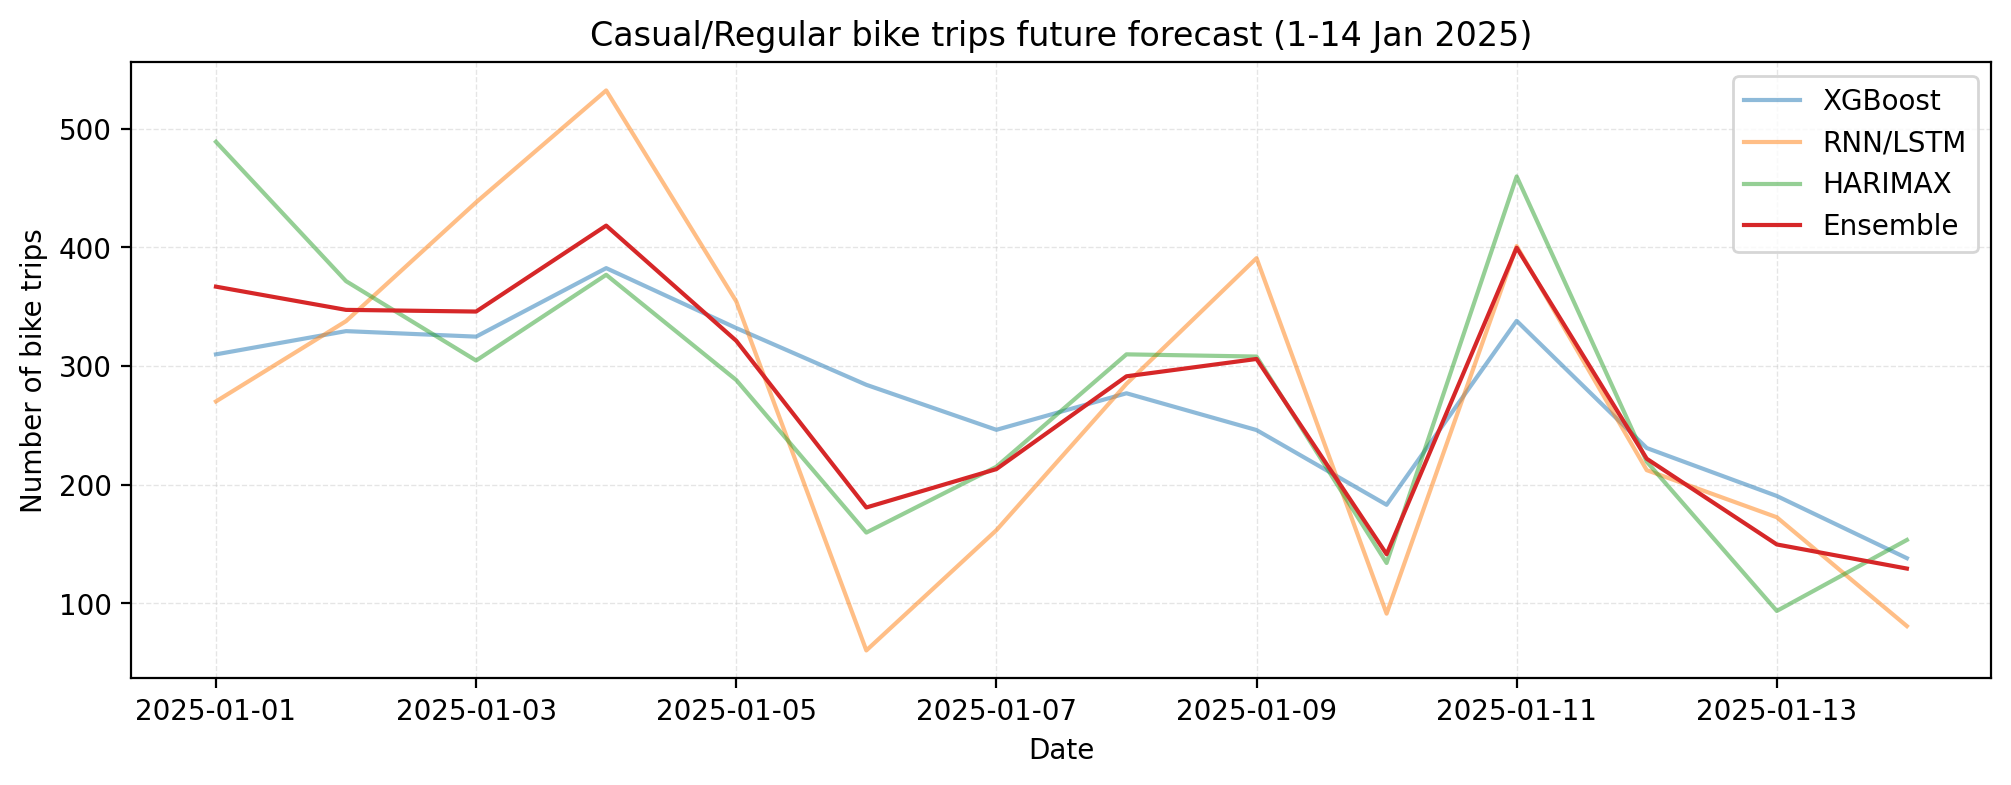

In [909]:
plt.plot(df["xgb"], label="XGBoost", alpha=0.5)
plt.plot(df["rnn"], label="RNN/LSTM", alpha=0.5)
plt.plot(df["harimax"], label="HARIMAX", alpha=0.5)
plt.plot(df["ensemble"], label="Ensemble")
plt.title("Casual/Regular bike trips future forecast (1-14 Jan 2025)")
plt.ylabel("Number of bike trips")
plt.xlabel("Date")
plt.legend()
plt.show()


---
\
[__<< Feature Engineering__](./04_Divvy_feature_engineering.ipynb) | [__XGBoost__](./05.1_Divvy_modeling_xgboost.ipynb) | [__RNN__](./05.2_Divvy_modeling_rnn.ipynb) | [__ARIMAX__](./05.3_Divvy_modeling_arimax.ipynb) | [__Ensemble__](./05.4_Divvy_modeling_ensemble.ipynb) | [__Home__](../README.md)

\
\
Divvy: Bike Sharing Forecast, _May 2025_